C:\Users\mcmoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 43, but rank is 9
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:               dlog_lic   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.489
Method:                 Least Squares   F-statistic:                     11.69
Date:                Fri, 26 Dec 2025   Prob (F-statistic):           5.48e-08
Time:                        15:32:05   Log-Likelihood:                 247.20
No. Observations:                 272   AIC:                            -408.4
Df Residuals:                     229   BIC:                            -253.4
Df Model:                          42                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.4894 

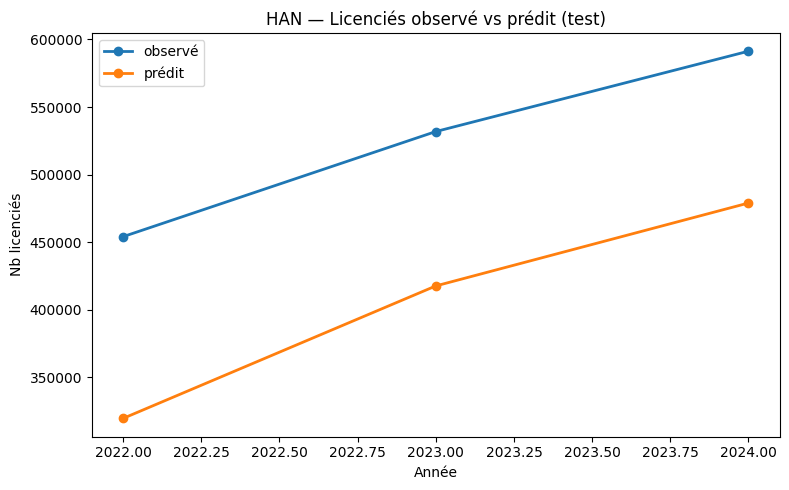

,code_sport,annee,nb_licencies,pred_nb_licencies
150,HAN,2022,454086,319585.03125
151,HAN,2023,531864,417608.78125
152,HAN,2024,591324,478960.84375


In [1]:
import pandas as pd

from model.feature_engineering import build_model_dataset
from model.modele_econo import fit_modele_croissance
from model.modele_predictif import train_ridge_predictif, plot_pred_sport


df_raw = pd.read_parquet("data/data_clean/data_complet.parquet")
df_model_full = build_model_dataset(df_raw)

# Écono
m = fit_modele_croissance(df_model_full)
print(m.summary())

# Prédictif
bundle = train_ridge_predictif(df_model_full)
print(bundle["metrics"])
plot_pred_sport(bundle, "HAN")
